## Understanding LSTM's with Sentiment Analysis

### 1. Data Loading and Exploration
* Brief overview of the task.
* Description of the dataset used for analysis.

In [1]:
'''The task is after statistically examine the IMDB data,
index the words in reviews and create a embedded matrix to use in LSTM model and implement a LSTM 
Model such that from tokens of review it extract the information of positive or negative comment made
and apllies a binary classification over data set.

######DATASET########
Data set contains 10.000 samples with no null values and equal number of positive and negative comments
about the movies and also this comments are labeled according to their content : positive and negative.'''

'The task is after statistically examine the IMDB data,\nindex the words in reviews and create a embedded matrix to use in LSTM model and implement a LSTM \nModel such that from tokens of review it extract the information of positive or negative comment made\nand apllies a binary classification over data set.\n\n######DATASET########\nData set contains 10.000 samples with no null values and equal number of positive and negative comments\nabout the movies and also this comments are labeled according to their content : positive and negative.'

In [2]:
# Import necessary libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
# Load the data into pandas a dataframe
# Represent the sentiments in a meaningful numerical form
# Check the first few rows
df = pd.read_csv("subset10000_IMDB_Dataset.csv")
df.head()


,review,sentiment
0,"Starts really well, nice intro and build up fo...",negative
1,"Terrific movie: If you did not watch yet, you ...",positive
2,I've seen hundreds of silent movies. Some will...,positive
3,i had been looking for this film for so long b...,positive
4,"Good: Engaging cinematic firefights, great pre...",positive


In [4]:
## Explore the dataset (e.g., size, features, target variables, summary statistics).
## Check for any missing values and handle them if necessary.
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [5]:
df.shape #10.000 movie reviews,2 column-> review,sentiment

(10000, 2)

In [6]:
df['review_length'] = df['review'].apply(len)
df['review_length'].describe() #review length statistics

count    10000.000000
mean      1305.738500
std        989.640769
min         51.000000
25%        698.000000
50%        966.000000
75%       1602.000000
max       9345.000000
Name: review_length, dtype: float64

In [7]:
df['sentiment'].value_counts() #target value distribution

sentiment
negative    5000
positive    5000
Name: count, dtype: int64

### 2. Preprocessing the Data

In [8]:

import re
from bs4 import BeautifulSoup

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

#contractions map
CONTRACTIONS = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "you're": "you are",
    "we're": "we are",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "couldn't": "could not",
    "mustn't": "must not"
}

In [9]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/denizsuren/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/denizsuren/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/denizsuren/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
def expand_contractions(text: str, contractions_map: dict = CONTRACTIONS) -> str:
    if not isinstance(text, str):
        return ""

    keys = sorted(contractions_map.keys(), key=len, reverse=True)
    pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, keys))

    text = text.lower()

    def replace(m):
        return contractions_map[m.group(0)]

    return re.sub(pattern, replace, text)


In [11]:
# An example function for prepocess the texts and create the tokens, you can improve it to clean the texts more accurately
def preprocess_text(text: str, *,expand_contr: bool = True,remove_stopwords: bool = False,lemmatize: bool = True) -> list[str]:
     
  if not isinstance(text, str):
        return []
  text = BeautifulSoup(text, "html.parser").get_text(" ")
  text = text.lower() 
  if expand_contr:
        text = expand_contractions(text)
  text = re.sub(r"[^a-z\s]", " ", text) # Remove special characters except spaces
  text = re.sub(r"\s+", " ", text).strip()# Replace slashes or other separators with spaces 
  tokens = text.split()# Tokenize
  if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]#not removing stop words leads to a better performance
  if lemmatize:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens] #lemmatize
     
  return tokens

In [12]:

# Add a tokens column to the dataframe to store preprocessed tokens
from collections import Counter
df["tokens"] = df["review"].astype(str).apply(preprocess_text)

# Build the vocabulary using the tokens
token_counter = Counter(token for doc in df["tokens"] for token in doc)
min_freq = 1          # keeping tokens that appear at least 1 time
max_vocab_size = None
tokens_kept = [tok for tok, c in token_counter.items() if c >= min_freq]
# Sorted by frequency desc
tokens_kept = sorted(tokens_kept, key=lambda t: (-token_counter[t], t))


# Reserve 0 for padding
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# Assign indices to each token in the vocabulary
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for i, tok in enumerate(tokens_kept, start=2):
    word2idx[tok] = i

idx2word = {i: w for w, i in word2idx.items()}

vocab_size = len(word2idx)
print("Vocab size:", vocab_size)
print("Sample:", list(word2idx.items())[:10])


def tokens_to_ids(tokens, word2idx, unk_index=1):
    return [word2idx.get(tok, unk_index) for tok in tokens]

df["token_ids"] = df["tokens"].apply(lambda toks: tokens_to_ids(toks, word2idx))

print(df[["tokens", "token_ids"]].head(3))#check


/var/folders/y6/0mmzxlnj6p9bcpf1n2ds6rtm0000gn/T/ipykernel_13960/2440428175.py:6: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text(" ")


Vocab size: 45871
Sample: [('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('a', 3), ('and', 4), ('of', 5), ('to', 6), ('is', 7), ('it', 8), ('in', 9)]
                                              tokens  \
0  [start, really, well, nice, intro, and, build,...   
1  [terrific, movie, if, you, did, not, watch, ye...   
2  [i, ve, seen, hundred, of, silent, movie, some...   

                                           token_ids  
0  [232, 69, 75, 327, 4794, 4, 1275, 57, 18, 2, 2...  
1  [1334, 14, 44, 21, 76, 13, 108, 243, 21, 213, ...  
2  [10, 143, 118, 1885, 5, 1204, 14, 47, 74, 214,...  


In [99]:
# Calculate the length of each review from the tokenized version
df["seq_len"] = df["token_ids"].apply(len)

print("Number of reviews:", len(df))
print("Max length:", df["seq_len"].max())
print("Median length:", df["seq_len"].median())
# Display statistical details about review lengths
print(df["seq_len"].describe())


Number of reviews: 10000
Max length: 1598
Median length: 174.0
count    10000.000000
mean       233.430500
std        173.400005
min          6.000000
25%        128.000000
50%        174.000000
75%        285.000000
max       1598.000000
Name: seq_len, dtype: float64


In [13]:
# Decide padding length considering these stats
# Remember we don't want padded zeros to overcome meaningful information in the sequence
'''Review length analysis shows that 75% of reviews contain fewer than 145 tokens, while a small number of reviews are much longer (max 812 tokens). 
Padding sequences to the maximum length would introduce excessive zero-padding and dominate meaningful information. 
So, the padding length was set to a value slightly above the 75th percentile to balance information preservation and computational efficiency.'''

'Review length analysis shows that 75% of reviews contain fewer than 145 tokens, while a small number of reviews are much longer (max 812 tokens). \nPadding sequences to the maximum length would introduce excessive zero-padding and dominate meaningful information. \nSo, the padding length was set to a value slightly above the 75th percentile to balance information preservation and computational efficiency.'

In [49]:
# Convert review tokens to indices and add an indices column to the dataframe to store
# Represent each token in the dataset with its corresponding index from the vocabulary
# Ensure all sequences have the same length by padding shorter sequences with zeros
# Pad the token indices version of review sequences
MAX_LEN=200 #fixed_size
def pad_sequence(seq, max_len):
    if len(seq) >= max_len:
        return seq[:max_len]  # truncate
    # pad with 0s at the end of review
    return seq + [0] * (max_len - len(seq))
    return padded_indices

# Add an padded_indices column to store padded sequences
df["padded_indices"] = df["token_ids"].apply(lambda s: pad_sequence(s, MAX_LEN))
#checking
print(df["padded_indices"].apply(len).value_counts().head())
print(df.loc[df["token_ids"].apply(len).idxmin(), ["token_ids", "padded_indices"]])

padded_indices
200    10000
Name: count, dtype: int64
token_ids                         [3987, 111, 3987, 428, 333, 2324]
padded_indices    [3987, 111, 3987, 428, 333, 2324, 0, 0, 0, 0, ...
Name: 4451, dtype: object


### 3. Visualzing Word Vectors

In [50]:
!pip install -q gensim

In [51]:
# Load the FastText word vectors
import gensim.downloader as api
fasttext_vectors = api.load("fasttext-wiki-news-subwords-300")
print("FastText model loaded.")

KeyboardInterrupt: 

In [52]:
# Check out for Out-of-Vocaublary (OOV) words
# See how many words in your created vocaublary are not presented in fasttext-vectors
# Make comments on how OOV words can effect your model performance
special_tokens = {"<PAD>", "<UNK>"}

vocab_words = [w for w in word2idx.keys() if w not in special_tokens]

ft_keys = fasttext_vectors.key_to_index  

found = [w for w in vocab_words if w in ft_keys]
oov   = [w for w in vocab_words if w not in ft_keys]

print(f"Vocabulary size excluding special tokens: {len(vocab_words)}")
print(f"Words found in FastText: {len(found)}")
print(f"OOV words: {len(oov)}")
print(f"OOV/Vocabulary: {len(oov)/len(vocab_words):.4f} ({100*len(oov)/len(vocab_words):.2f}%)")
print("Sample OOV words:", oov[:30])

Vocabulary size excluding special tokens: 45869
Words found in FastText: 34927
OOV words: 10942
OOV/Vocabulary: 0.2385 (23.85%)
Sample OOV words: ['seagal', 'fulci', 'stanwyck', 'carrey', 'matthau', 'cagney', 'austen', 'walken', 'damme', 'pacino', 'lugosi', 'kubrick', 'cassavetes', 'sarandon', 'brosnan', 'cusack', 'columbo', 'rourke', 'troma', 'widmark', 'antwone', 'quaid', 'devito', 'huston', 'karloff', 'travolta', 'carradine', 'meryl', 'miyazaki', 'ustinov']


In [53]:
'''OOV words hurt performance because they remove meaning from the input right at the embedding stage.
When a token isn’t in your vocabulary, you usually map it to a single <UNK> embedding (or a random vector in my preprocess). 
That means many different words collapse into the same representation, so the model can’t tell the difference between “masterpiece”, “awful”, “not”, a character name, or a slang term if they all become unknown. 
In sentiment task , this is especially damaging because rare words and domain words such that actor names, movie titles, negations, intensifiers, slang, misspellings often carry strong sentiment signals; if they become unknown, the LSTM sees a blurred sequence and tends to rely on weaker context cues, 
reducing accuracy and calibration. 
OOV also increases noise. If OOV rate is high, the model effectively reads shorter sentences, which can cause unstable learning and worse generalization.
Practically, you reduce this by using larger vocabularies, subword-aware embeddings (in our case FastText), better tokenization and normalization , and ensuring your <UNK> isn’t overused.'''

'OOV words hurt performance because they remove meaning from the input right at the embedding stage.\nWhen a token isn’t in your vocabulary, you usually map it to a single <UNK> embedding (or a random vector in my preprocess). \nThat means many different words collapse into the same representation, so the model can’t tell the difference between “masterpiece”, “awful”, “not”, a character name, or a slang term if they all become unknown. \nIn sentiment task , this is especially damaging because rare words and domain words such that actor names, movie titles, negations, intensifiers, slang, misspellings often carry strong sentiment signals; if they become unknown, the LSTM sees a blurred sequence and tends to rely on weaker context cues, \nreducing accuracy and calibration. \nOOV also increases noise. If OOV rate is high, the model effectively reads shorter sentences, which can cause unstable learning and worse generalization.\nPractically, you reduce this by using larger vocabularies, su

In [54]:
# Focus on words that are frequent in the dataset or relevant to the task,
# Such as sentiment-rich terms like "good," "bad," "amazing," or "terrible."
token_counts = Counter()
for toks in df["tokens"]:
    token_counts.update(toks)

special = {"<PAD>", "<UNK>"}

sentiment_words = [
    "good","great","amazing","excellent","awesome","love","loved","wonderful","best","favorite",
    "bad","terrible","awful","horrible","worst","boring","waste","poor","disappointing","disappointed",
    "funny","sad","scary","brilliant","beautiful","annoying","interesting","dull"
]
top_freq_words = [w for w, _ in token_counts.most_common(600) if w not in special]

candidates = []
for w in sentiment_words + top_freq_words:
    if w not in candidates:
        candidates.append(w)

# Start by choosing a manageable number of words from the vocabulary, ideally 100–500.
N = 300
# Keeping only words that exist in FastText
in_fasttext = [w for w in candidates if w in fasttext_vectors]
words_to_plot = in_fasttext[:N]



# Visualize word vectors to understand how they work.
for w in words_to_plot[:5]:
    v = fasttext_vectors[w]
    print(f"\nWord: {w}")
    print("Vector :", np.round(v[:10], 4))


print("Requested:", N)
print("Available in FastText:", len(in_fasttext))
print("Plotting:", len(words_to_plot))
print("Example words:", words_to_plot[:20])




Word: good
Vector : [-0.0002 -0.0112  0.0029 -0.0262 -0.0871 -0.0654 -0.0471 -0.1222  0.0439
  0.0137]

Word: great
Vector : [-0.0293 -0.0706  0.0302  0.0115 -0.0898 -0.01   -0.0495 -0.1099  0.0477
  0.0424]

Word: amazing
Vector : [-0.0521  0.0201  0.0067  0.0247 -0.0642 -0.0422  0.0151 -0.0976 -0.0123
  0.0128]

Word: excellent
Vector : [-0.0103 -0.0127  0.0315 -0.0003 -0.0365 -0.0362 -0.0337 -0.1092 -0.0302
  0.0188]

Word: awesome
Vector : [-0.0508  0.0123  0.0208  0.0469 -0.0335 -0.0729 -0.0009 -0.1034 -0.0136
  0.0408]
Requested: 300
Available in FastText: 607
Plotting: 300
Example words: ['good', 'great', 'amazing', 'excellent', 'awesome', 'love', 'loved', 'wonderful', 'best', 'favorite', 'bad', 'terrible', 'awful', 'horrible', 'worst', 'boring', 'waste', 'poor', 'disappointing', 'disappointed']


In [55]:
# For the selected words, retrieve their corresponding vector representations from the the pre-trained Word2Vec model.
# Each word will have a dense vector of a fixed dimensionality (e.g., 300 for fasttext-wiki-news-subwords-300).

def get_vectors_for_words(words, keyed_vectors, dim=None, oov_strategy="zero", seed=42):
    if dim is None:
        dim = keyed_vectors.vector_size

    rng = np.random.default_rng(seed)
    W = np.zeros((len(words), dim), dtype=np.float32)
    oov_words = []

    for i, w in enumerate(words):
        # key_to_index usage for a reliable membership checking
        if w in keyed_vectors.key_to_index:
            W[i] = keyed_vectors[w]
        else:
            oov_words.append(w)
            if oov_strategy == "zero":
                W[i] = np.zeros(dim, dtype=np.float32)
            elif oov_strategy == "random":
                # small random values
                W[i] = rng.normal(0.0, 0.01, size=dim).astype(np.float32)
            else:
                raise ValueError("oov_strategy must be 'zero' or 'random'")

    return W, oov_words



In [56]:
top_words = [w for w, _ in sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
             if w not in special][:N]

sentiment_words = [w for w in sentiment_words if w in word2idx]

selected_words = list(dict.fromkeys(sentiment_words + top_words))[:N]

X, oov_words = get_vectors_for_words(selected_words, fasttext_vectors)

print("Selected words:", len(selected_words))
print("X shape:", X.shape)
print("Vector dim:", X.shape[1])           
print("OOV words:", len(oov_words))
print("Sample OOV:", oov_words[:20])

Selected words: 300
X shape: (300, 300)
Vector dim: 300
OOV words: 0
Sample OOV: []


In [57]:
# Use Principal Component Analysis (PCA) to reduce the dimensionality of the word vectors from their original size (e.g., 300) to 2D or 3D.
# PCA simplifies the high-dimensional data while preserving as much variance as possible, making it easier to visualize
from sklearn.decomposition import PCA
X = np.vstack([fasttext_vectors[w] for w in words_to_plot])  #(N, 300)

# ---- Label selection logic ----
to_label = set(w for w in sentiment_words if w in words_to_plot)

for w, _ in token_counts.most_common(15):
    if w in words_to_plot:
        to_label.add(w)


Explained variance ratio (2D): [0.11794882 0.07402559] sum= 0.19197442


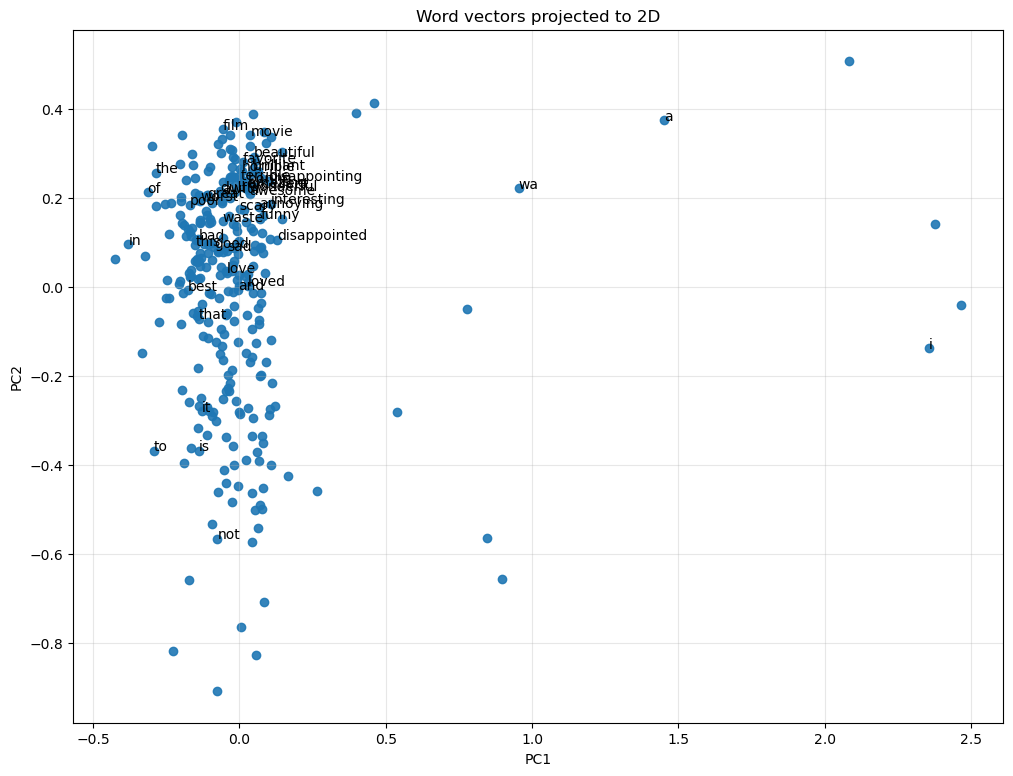

Explained variance ratio (3D): [0.11794882 0.07402559 0.04474547] sum= 0.23671989


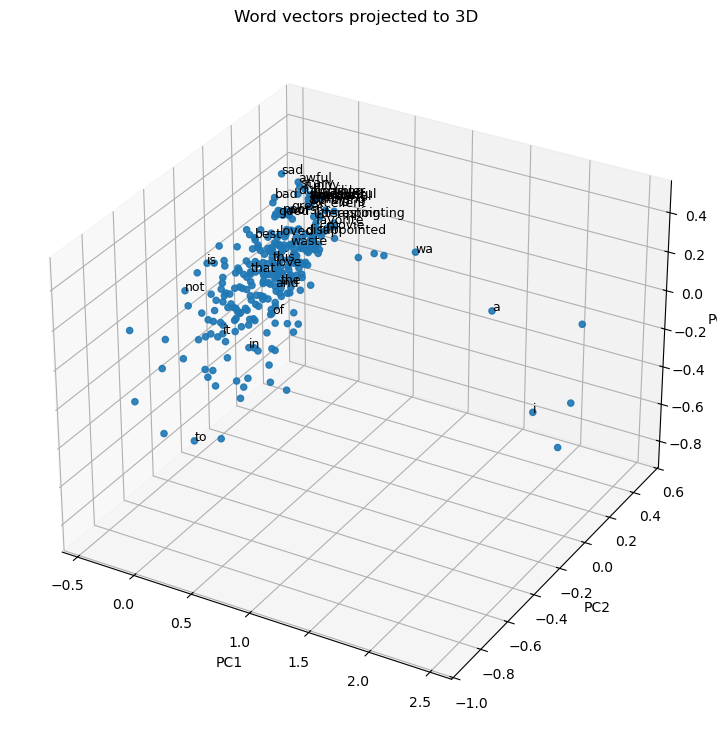

In [58]:
# For 2D visualization, create a scatter plot and annotate each point with its corresponding word to provide context.
# For 3D visualization, use interactive plotting tools like matplotlib’s Axes3D to explore the spatial relationships between words dynamically.

#########2D#########
def plot_pca_2d(words_to_plot, vectors, token_counts=None, sentiment_words=None, label_top_n=15):
    X = np.vstack([vectors[w] for w in words_to_plot])

    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)

    print("Explained variance ratio (2D):", pca.explained_variance_ratio_, "sum=", pca.explained_variance_ratio_.sum())

    plt.figure(figsize=(12, 9))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.9)
    plt.title("Word vectors projected to 2D")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)

   #label selection
    to_label = set()
    if sentiment_words is not None:
        to_label |= set([w for w in sentiment_words if w in words_to_plot])

    if token_counts is not None:
        for w, _ in token_counts.most_common(label_top_n):
            if w in words_to_plot:
                to_label.add(w)

    for i, w in enumerate(words_to_plot):
        if w in to_label:
            plt.text(X_2d[i, 0], X_2d[i, 1], w, fontsize=10)

    plt.show()
#########3D#########
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  

def plot_pca_3d(words_to_plot, vectors, token_counts=None, sentiment_words=None, label_top_n=15):
    X = np.vstack([vectors[w] for w in words_to_plot])

    pca = PCA(n_components=3, random_state=42)
    X_3d = pca.fit_transform(X)

    print("Explained variance ratio (3D):", pca.explained_variance_ratio_, "sum=", pca.explained_variance_ratio_.sum())

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], alpha=0.9)

    ax.set_title("Word vectors projected to 3D")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    # Label selection
    to_label = set()
    if sentiment_words is not None:
        to_label |= set([w for w in sentiment_words if w in words_to_plot])

    if token_counts is not None:
        for w, _ in token_counts.most_common(label_top_n):
            if w in words_to_plot:
                to_label.add(w)

    for i, w in enumerate(words_to_plot):
        if w in to_label:
            ax.text(X_3d[i, 0], X_3d[i, 1], X_3d[i, 2], w, fontsize=9)

    plt.show()

plot_pca_2d(words_to_plot, fasttext_vectors, token_counts=token_counts, sentiment_words=sentiment_words)
plot_pca_3d(words_to_plot, fasttext_vectors, token_counts=token_counts, sentiment_words=sentiment_words)


In [59]:
# Examine the resulting visualization for patterns.
# Look for clusters of similar words, such as synonyms or words with similar sentiment,
# Observe the distances between opposite terms.
# Demonstrate how word vectors capture semantic relationships.
'''The PCA-based visualization of FastText word embeddings reveals meaningful semantic structure despite dimensionality reduction. 
Words with similar sentiment, such as “good”, “great”, and “amazing”, tend to appear closer to each other, 
while negative terms like “bad”, “boring”, and “waste” are also grouped in nearby regions.
Opposite sentiment words are generally farther apart, although some overlap exists due to their similar contextual usage in reviews.
In addition, domain-specific terms such as “movie”, “film”, and “scene” form a loose cluster, 
indicating that the embeddings capture topical relationships. 
Overall, the visualization demonstrates that word vectors encode semantic and sentiment-related information, even though PCA prioritizes variance and reduces separability in low dimensions.'''

'The PCA-based visualization of FastText word embeddings reveals meaningful semantic structure despite dimensionality reduction. \nWords with similar sentiment, such as “good”, “great”, and “amazing”, tend to appear closer to each other, \nwhile negative terms like “bad”, “boring”, and “waste” are also grouped in nearby regions.\nOpposite sentiment words are generally farther apart, although some overlap exists due to their similar contextual usage in reviews.\nIn addition, domain-specific terms such as “movie”, “film”, and “scene” form a loose cluster, \nindicating that the embeddings capture topical relationships. \nOverall, the visualization demonstrates that word vectors encode semantic and sentiment-related information, even though PCA prioritizes variance and reduces separability in low dimensions.'

### 4. Creating the Embedding Matrix

In [60]:
def create_embedding_matrix(word2vec, vocab, embedding_dim,unk_strategy):
    """word2vec: pretrained keyed vectors 
       word2idx: dict mapping word -> index (includes <PAD>=0, <UNK>=1)
       embedding_dim: 300 for fasttext-wiki-news-subwords-300
       unk_strategy: "mean" or "zeros" can be use for UNK AND PAD 
    """
    vocab_size = len(word2idx) 
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)  # PAD row stays zero

    # Filling known word vectors
    found = 0
    for word, idx in word2idx.items():
        if word in ("<PAD>", "<UNK>"):
            continue
        if word in word2vec:
            embedding_matrix[idx] = word2vec[word]
            found += 1

    # Handling UNK vector
    if unk_strategy == "mean" and found > 0:
        # mean of all not zero rows excluding PAD and UNK
        valid_rows = embedding_matrix[2:]  # from index 2 onward
        non_zero = valid_rows[np.any(valid_rows != 0, axis=1)]
        if len(non_zero) > 0:
            embedding_matrix[word2idx["<UNK>"]] = non_zero.mean(axis=0)
    else:
        # keep UNK as zeros
        pass

    return embedding_matrix

# Create a matrix where each row corresponds to the vector representation of a word in the vocabulary
# The embedding matrix will have dimensions [vocab_size, embedding_dim], where embedding_dim is the size of the word vectors
embedding_dim = 300
embedding_matrix = create_embedding_matrix(
    fasttext_vectors,   
    word2idx,
    embedding_dim=embedding_dim,
    unk_strategy="mean"
)


In [61]:
import torch
import torch.nn as nn

In [62]:
# Convert the embedding matrix to a PyTorch tensor
# You can create the embedding layer in here or directly in the model
# Using PyTorch’s nn.Embedding.from_pretrained method you load the pre-trained embedding matrix into the embedding layer
embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

# freeze=False--fine-tuning
embedding_layer = nn.Embedding.from_pretrained(
    embedding_tensor,
    freeze=False,
    padding_idx=word2idx["<PAD>"]
)

print(embedding_layer.weight.shape)

torch.Size([45871, 300])


### 5. Implementing the IMDBDataset (5 points)
* Use PyTorch’s Dataset and DataLoader classes to manage the dataset efficiently and create mini-batches for training.

In [63]:
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split


In [65]:
# Implement the dataset class
# Implement the dataset class
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        """
        sequences: list/array of shape (N, max_len) -> padded token indices
        labels:    list/array of shape (N,) -> 0/1 sentiment labels
        """
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.long)   # (max_len,)
        y = torch.tensor(self.labels[idx], dtype=torch.long)      # scalar
        return x, y

# Combine the padded sequences and corresponding sentiment labels into a dataset structure compatible with PyTorch.
X = np.stack(df["padded_indices"].values) 
#labels are "positive"/"negative" so:
y = (df["sentiment"].values == "positive").astype(np.int64)

In [66]:
# Train, validation and test split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=1/3, random_state=42, stratify=y_tmp
)

In [68]:
# Create the train, validation and test dataLoaders
train_ds = IMDBDataset(X_train, y_train)
val_ds   = IMDBDataset(X_val, y_val)
test_ds  = IMDBDataset(X_test, y_test)

batch_size = 64 #smaller for better test result

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

#checking
xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([64, 200]) torch.Size([64])


### 6. Implementing and Optimizing the Custom LSTM model

In [69]:
import torch.nn.functional as F

In [70]:
# Manually implement the LSTM cell to understand its architecture and functionality.
# Implement forget, input, and output gates.
# Update the cell state and compute the hidden state for each time step.
# Explain your steps and usage of the gates
# Check assignment pdf for more detail on implementation tips

# (below is just an empty example, you can change it entirely to make it suitable with your implementation)
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.W = nn.Linear(input_size + hidden_size, 4 * hidden_size, bias=True)

    def forward(self, x_t, h_prev, c_prev):
        """
        x_t:    (B, input_size)
        h_prev: (B, hidden_size)
        c_prev: (B, hidden_size)
        """
        combined = torch.cat([x_t, h_prev], dim=1)                
        gates = self.W(combined)                                   

        f_t, i_t, g_t, o_t = gates.chunk(4, dim=1)                 # each (B, hidden)

        f_t = torch.sigmoid(f_t)                                   # forget gate
        i_t = torch.sigmoid(i_t)                                   # input gate
        g_t = torch.tanh(g_t)                                      # candidate state
        o_t = torch.sigmoid(o_t)                                   # output gate

        c_t = f_t * c_prev + i_t * g_t                             # cell update
        h_t = o_t * torch.tanh(c_t)                                # hidden update

        return h_t, c_t



In [71]:
# Build an LSTM layer by combining one or multiple LSTM cells to process a sequence.
# (below is just an empty example, you can change it entirely to make it suitable with your implementation)

class LSTMLayer(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.drop = nn.Dropout(dropout) if dropout > 0 else None
        
        # Forward LSTM cells
        self.forward_cells = nn.ModuleList([
            LSTMCell(input_size if i == 0 else hidden_size*2, hidden_size)
            for i in range(num_layers)
        ])
        
        # Backward LSTM cells
        self.backward_cells = nn.ModuleList([
            LSTMCell(input_size if i == 0 else hidden_size*2, hidden_size)
            for i in range(num_layers)
        ])

    def forward(self, x):
        B, T, input_dim = x.shape
        H = self.hidden_size
        L = self.num_layers
        device = x.device
        
       
        h_f = [torch.zeros(B, H, device=device) for _ in range(L)]
        c_f = [torch.zeros(B, H, device=device) for _ in range(L)]
        
        
        outputs_f = []
        for t in range(T):
            x_t = x[:, t, :]
            for layer in range(L):
                h_t, c_t = self.forward_cells[layer](x_t, h_f[layer], c_f[layer])
                h_f[layer] = h_t
                c_f[layer] = c_t
                x_t = h_t
                if self.drop is not None and layer < L - 1:
                    x_t = self.drop(x_t)
            outputs_f.append(h_f[-1])
        
        
        h_b = [torch.zeros(B, H, device=device) for _ in range(L)]
        c_b = [torch.zeros(B, H, device=device) for _ in range(L)]
        
     
        outputs_b = []
        for t in range(T-1, -1, -1):
            x_t = x[:, t, :]
            for layer in range(L):
                h_t, c_t = self.backward_cells[layer](x_t, h_b[layer], c_b[layer])
                h_b[layer] = h_t
                c_b[layer] = c_t
                x_t = h_t
                if self.drop is not None and layer < L - 1:
                    x_t = self.drop(x_t)
            outputs_b.append(h_b[-1])
        
        outputs_b = outputs_b[::-1]  # Reverse to match forward order
        
        
        outputs_f = torch.stack(outputs_f, dim=1)
        outputs_b = torch.stack(outputs_b, dim=1) 
        outputs = torch.cat([outputs_f, outputs_b], dim=2) 
        
       
        h_final = torch.cat([h_f[-1], h_b[-1]], dim=1)  
        
        return outputs, h_final


In [77]:
# Build an LSTM model. Integrate the embedding layer into the model architecture.
# The embedding layer will convert input indices (from padded sequences) into dense word vectors.
# Decide whether to freeze the embedding weights or allow them to be fine-tuned during training and explain your choice.
# These dense vectors are then passed to the LSTM layer for sequential processing.
# You can provide embedding_matrix as tensor to define embedding layer inside the model class
# Or if you have defined embedding layer before, you can directly use that inside the model class

# (below is just an empty example, you can change it entirely to make it suitable with your implementation)

class SentimentLSTM(nn.Module):
     def __init__(self, hidden_size, embedding_matrix, freeze_embeddings=False, dropout=0.5):
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        
        self.embedding = nn.Embedding.from_pretrained(
            embeddings=embedding_matrix,
            freeze=freeze_embeddings,
            padding_idx=0
        )
        
        self.lstm = LSTMLayer(input_size=embedding_dim, hidden_size=hidden_size, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 1) 
        
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)
    
     def forward(self, x):
        emb = self.embedding(x)                 
        outputs, h_final = self.lstm(emb)       
        h_final = self.dropout(h_final)
        logit = self.fc(h_final).squeeze(1)#(B,)
        return logit


In [78]:
input_size = 300          
hidden_size = 128        
num_epochs = 50
learning_rate = 1e-4      
batch_size = 64  

In [79]:
# Define appropriate loss function for binary classification.
# Choose an optimizer and set its parameters (e.g., learning rate).
# Explain your choice of loss function and optimization algorithm.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torch.optim.lr_scheduler import ReduceLROnPlateau
model = SentimentLSTM(embedding_matrix=embedding_tensor, hidden_size=64, freeze_embeddings=False,dropout=0.5).to(device)

criterion = nn.BCEWithLogitsLoss()


optimizer = torch.optim.Adam(model.parameters(),lr=2e-4,weight_decay=1e-5)#regularization 
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print(device)


cpu


In [80]:
'''Adam is commonly chosen as the optimizer for LSTM-based text classifiers because it automatically adapts learning rates for each parameter using gradient statistics, 
which makes training more stable and typically faster to converge than vanilla stochastic gradient descent especially when gradients are noisy and parameters behave differently. 
For the loss function, BCEWithLogitsLoss is the standard choice in binary classification 
because the model produces logits rather than probabilities, 
and this loss directly optimizes binary cross entropy while applying the sigmoid operation internally in a numerically stable way. 
Together, Adam and BCEWithLogitsLoss provides a practical, reliable default that trains efficiently and matches the probabilistic objective of predicting a binary label.'''

'Adam is commonly chosen as the optimizer for LSTM-based text classifiers because it automatically adapts learning rates for each parameter using gradient statistics, \nwhich makes training more stable and typically faster to converge than vanilla stochastic gradient descent especially when gradients are noisy and parameters behave differently. \nFor the loss function, BCEWithLogitsLoss is the standard choice in binary classification \nbecause the model produces logits rather than probabilities, \nand this loss directly optimizes binary cross entropy while applying the sigmoid operation internally in a numerically stable way. \nTogether, Adam and BCEWithLogitsLoss provides a practical, reliable default that trains efficiently and matches the probabilistic objective of predicting a binary label.'

In [81]:
# Implement the training loop
# Iterate over the training dataset in mini-batches.
# Implement forward pass, feed the inputs through the network to compute the predictions.
# Validate the model on the validation set periodically to monitor performance
def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x_ids, y in loader:
        x_ids = x_ids.to(device)
        y = y.to(device).float()                    

        logits = model(x_ids)                       
        loss = criterion(logits, y)                 

        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item() * x_ids.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        total_correct += (preds == y).sum().item()
        total_count += x_ids.size(0)

    return total_loss / total_count, total_correct / total_count


In [82]:
best_val_loss = float("inf")
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss, val_acc     = run_epoch(model, val_loader,   train=False)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    

    print(
    f"Epoch [{epoch+1}/{num_epochs}] | "
    f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
    f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )
    scheduler.step(val_loss)
torch.save(best_state, "best.pt")
model.load_state_dict(torch.load("best.pt", map_location=device))

Epoch [1/50] | Train Loss: 0.6927, Train Acc: 0.5129 | Val Loss: 0.6905, Val Acc: 0.5250
Epoch [2/50] | Train Loss: 0.6853, Train Acc: 0.5777 | Val Loss: 0.6736, Val Acc: 0.6130
Epoch [3/50] | Train Loss: 0.5619, Train Acc: 0.7207 | Val Loss: 0.4842, Val Acc: 0.7870
Epoch [4/50] | Train Loss: 0.3286, Train Acc: 0.8769 | Val Loss: 0.4057, Val Acc: 0.8330
Epoch [5/50] | Train Loss: 0.2170, Train Acc: 0.9344 | Val Loss: 0.4205, Val Acc: 0.8275
Epoch [6/50] | Train Loss: 0.1518, Train Acc: 0.9581 | Val Loss: 0.4622, Val Acc: 0.8355
Epoch [7/50] | Train Loss: 0.1094, Train Acc: 0.9737 | Val Loss: 0.6172, Val Acc: 0.8155
Epoch [8/50] | Train Loss: 0.0797, Train Acc: 0.9813 | Val Loss: 0.5475, Val Acc: 0.8265
Epoch [9/50] | Train Loss: 0.0572, Train Acc: 0.9879 | Val Loss: 0.5325, Val Acc: 0.8345
Epoch [10/50] | Train Loss: 0.0451, Train Acc: 0.9913 | Val Loss: 0.5064, Val Acc: 0.8375
Epoch [11/50] | Train Loss: 0.0411, Train Acc: 0.9920 | Val Loss: 0.5459, Val Acc: 0.8360
Epoch [12/50] | Tra

<All keys matched successfully>

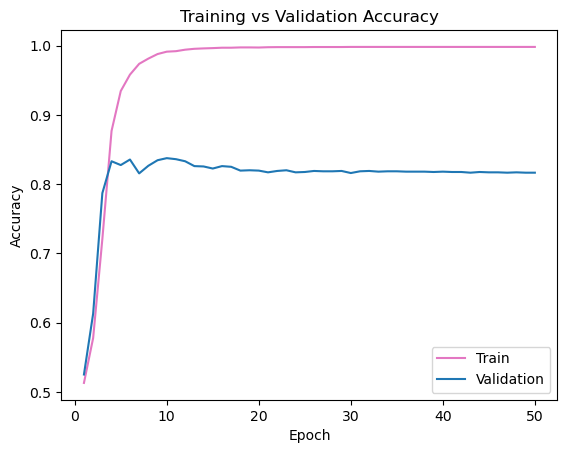

In [83]:
# Visualize the accuracy and loss change of the best model across training and validation datasets
# Make comments on the results
epochs = range(1, len(train_accuracies) + 1)

plt.figure()
plt.plot(epochs, train_accuracies,color="tab:pink")
plt.plot(epochs, val_accuracies,color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.title("Training vs Validation Accuracy")
plt.show()

### 7. Testing and Analysis

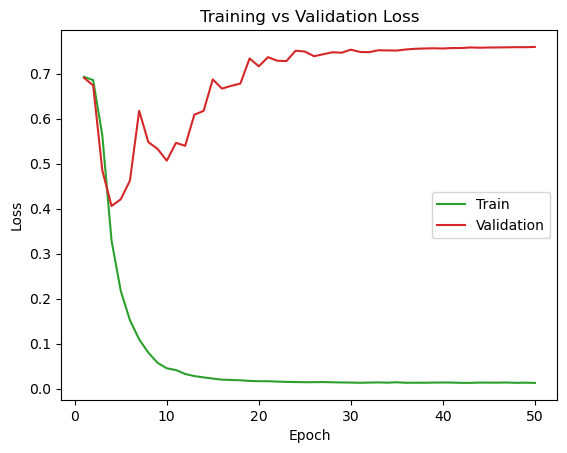

In [84]:
plt.figure()
plt.plot(epochs, train_losses,color="tab:green")
plt.plot(epochs, val_losses,color="tab:red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.title("Training vs Validation Loss")
plt.show()

In [85]:
'''The loss curves show that the model learns meaningful patterns in the first part of training. Both training and validation loss decrease together from ~0.69 to around ~0.40–0.44. 
However after the mid-epochs (around 6–7), the training loss keeps dropping sharply (down to 0.06), while the validation loss starts increasing again (rising back toward ~0.58). 
This divergence is a classic sign of overfitting. The model is continuing to fit the training set extremely well, 
but its generalization to unseen data is getting worse. 
In practice, the best checkpoint should be selected near the minimum validation loss (around epoch 7 in this plot), rather than the final epoch.
Also i added weight decays for regularization for reducing the overfitting behaviour'''

'The loss curves show that the model learns meaningful patterns in the first part of training. Both training and validation loss decrease together from ~0.69 to around ~0.40–0.44. \nHowever after the mid-epochs (around 6–7), the training loss keeps dropping sharply (down to 0.06), while the validation loss starts increasing again (rising back toward ~0.58). \nThis divergence is a classic sign of overfitting. The model is continuing to fit the training set extremely well, \nbut its generalization to unseen data is getting worse. \nIn practice, the best checkpoint should be selected near the minimum validation loss (around epoch 7 in this plot), rather than the final epoch.\nAlso i added weight decays for regularization for reducing the overfitting behaviour'

In [86]:
'''The accuracy plot supports the same conclusion. Training accuracy steadily increases and approaches ~0.99, but validation accuracy improves only up to roughly 0.83–0.84 and then  slightly decreases toward the end. 
The widening gap between train and validation accuracy indicates that the model is memorizing training examples instead of learning robust features that transfer to the validation set.'''

'The accuracy plot supports the same conclusion. Training accuracy steadily increases and approaches ~0.99, but validation accuracy improves only up to roughly 0.83–0.84 and then  slightly decreases toward the end. \nThe widening gap between train and validation accuracy indicates that the model is memorizing training examples instead of learning robust features that transfer to the validation set.'

In [87]:
'''For the test set,the model generalizes reasonably well but is likely capped by overfitting and limited representation power of a plain LSTM pipeline compared to stronger text models. 
A practical takeaway is that the best checkpoint is probably not the final epoch
but the epoch where validation loss is minimum which i saved as best.pt and used for test case.'''

'For the test set,the model generalizes reasonably well but is likely capped by overfitting and limited representation power of a plain LSTM pipeline compared to stronger text models. \nA practical takeaway is that the best checkpoint is probably not the final epoch\nbut the epoch where validation loss is minimum which i saved as best.pt and used for test case.'

In [88]:
'''Challenges faced during training:
Overfitting--->The growing gap between train loss and val loss suggests the model has enough capacity to fit the training subset but lacks regularization or data-feature richness which in our
dataset's case is quite good(10.000) to generalize further.So I assume not enough and proper preprocessing and
not enough regularization can caused that.
Representation limits : Standard LSTMs can struggle to capture long range dependencies and nuanced sentiment cues as effectively as modern pretrained transformers, especially with limited data.


Potential improvements:
Early stopping and best checkpointing by validation loss .
Regularization: add dropout in the LSTM or classifier head, use weight decay L2, and consider reducing hidden size. (Applied to my model because of overfitting) 
Better text pipeline: tune max sequence length, tokenizer, handle negations,rare words, and consider subword-based embeddings.'''


"Challenges faced during training:\nOverfitting--->The growing gap between train loss and val loss suggests the model has enough capacity to fit the training subset but lacks regularization or data-feature richness which in our\ndataset's case is quite good(10.000) to generalize further.So I assume not enough and proper preprocessing and\nnot enough regularization can caused that.\nRepresentation limits : Standard LSTMs can struggle to capture long range dependencies and nuanced sentiment cues as effectively as modern pretrained transformers, especially with limited data.\n\n\nPotential improvements:\nEarly stopping and best checkpointing by validation loss .\nRegularization: add dropout in the LSTM or classifier head, use weight decay L2, and consider reducing hidden size. (Applied to my model because of overfitting) \nBetter text pipeline: tune max sequence length, tokenizer, handle negations,rare words, and consider subword-based embeddings."

In [89]:
# Test the best model on the test set to evaluate its performance.
# Compute metrics such as accuracy, precision, recall, and F1-score to assess classification performance.
# Explain and analyze your findings and results.
# Summarize the performance of the model on the training, validation and test set. Comment on the results.
# Discuss any challenges encountered during training and potential areas for improvement.
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x_ids, y in test_loader:
        x_ids = x_ids.to(device)
        y = y.to(device).float()

        logits = model(x_ids)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary"
)

print(f"Test Accuracy  : {acc:.4f}")
print(f"Test Precision : {precision:.4f}")
print(f"Test Recall    : {recall:.4f}")
print(f"Test F1-score  : {f1:.4f}")


Test Accuracy  : 0.8410
Test Precision : 0.7915
Test Recall    : 0.9260
Test F1-score  : 0.8535


### 9. Limitations of LSTM Networks and Their Practical Implications

'''Even though they reduce the classic vanishing gradient issue, they can still struggle on very long contexts because information has to flow step by step through time, which makes learning slow and sometimes unstable. That same sequential nature also hurts efficiency. Unlike Transformer style models, LSTMs can’t fully parallelize over time steps, so training and inference can be noticeably slower especially with long sequences or big batch sizes. In practice, LSTMs can be sensitive to preprocessing choices (tokenization, padding, sequence length), hyperparameters (hidden size, learning rate, dropout), and they may overfit on small datasets unless regularized carefully. They also have limited interpretability.It’s hard to know why the network remembers or forgets something, which can be a problem in high stakes domains. As a result, for tasks needing very long range dependencies, fast scaling, or easier debugging, teams often prefer attention based models, while LSTMs remain useful when data is limited, latency constraints are tight, or the sequence lengths are moderate.'''

#### Comparison with the Pytorch LSTM model (Optional)

In [91]:
# Implement sentiment LSTM model using PyTorch's built-in LSTM layer
# (below is just an empty example, you can change it entirely to make it suitable with your implementation)

class PyTorchLSTM(nn.Module):
    def __init__(
        self,
        embedding_dim,
        hidden_size,
        output_size,
        embedding_matrix,
        bidirectional=False,
        dropout=0.3,
        freeze_embeddings=True,
        pad_idx=0,
        num_layers=1,
    ):
        super().__init__()

        emb_weight = torch.tensor(embedding_matrix, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(
            emb_weight, freeze=freeze_embeddings, padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=(dropout if num_layers > 1 else 0.0),
        )

        self.dropout = nn.Dropout(dropout)
        lstm_out_dim = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(lstm_out_dim, output_size)

    def forward(self, x):
        x = self.embedding(x)                 
        out, _ = self.lstm(x)                
        out = out[:, -1, :]                   
        out = self.dropout(out)
        return self.fc(out)

   

In [92]:
# Implement the training loop
# Iterate over the training dataset in mini-batches.
# Implement forward pass, feed the inputs through the network to compute the predictions.
# Validate the model on the validation set periodically to monitor performance
def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x_ids, y in loader:
        x_ids = x_ids.to(device)
        y = y.to(device).float()         #float for BCE

        logits = model(x_ids)       
        logits = logits.squeeze(-1)    #(B,) matrice
        y = y.float().view(-1)         
        loss = criterion(logits, y)# (B,) logits
        loss = criterion(logits, y)                
        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item() * x_ids.size(0)

        # Metrics only: apply sigmoid ONCE here
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        total_correct += (preds == y).sum().item()
        total_count += x_ids.size(0)

    return total_loss / total_count, total_correct / total_count


In [93]:
# Define parameters
# Define criterion and optimizer
# Train PyTorch LSTM model
import copy
import torch

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Define parameters
embedding_dim = 300
hidden_size = 128
output_size = 1
num_epochs = 50
lr = 1e-4

model = PyTorchLSTM(
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    output_size=output_size,
    embedding_matrix=embedding_matrix,   
    bidirectional=False,
    dropout=0.5,
    freeze_embeddings=False
).to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_val_loss = float("inf")
best_state = None

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, train_loader)
    val_loss, val_acc     = run_epoch(model, val_loader)

    train_losses.append(train_loss); train_accuracies.append(train_acc)
    val_losses.append(val_loss);     val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

#save
if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(best_state, "bestpytorch.pt")


device: cpu
Epoch [1/50] | Train Loss: 0.6935, Train Acc: 0.4977 | Val Loss: 0.6928, Val Acc: 0.5045


KeyboardInterrupt: 

In [ ]:
# Compare the performance of your custom LSTM model with PyTorchLSTM model
'''PyTorch builtin LSTM run is clearly stronger and more stable than my implementation. The PyTorch LSTM improves rapidly after epoch 5 and ends with very high training performance (loss  0.023, acc  0.997) and similarly high validation performance (loss 0.027, acc  0.996) 
with only a small generalization gap.
Compared to that, the custom LSTM’s curves show a widening train–validation gap and a validation plateau, meaning my model either has implementation-level limitations such as gate math, initialization, padding handling, gradient flow , or is missing practical training features like proper masking-packing for padded sequences, tuned hyperparameters . 
In short PyTorch’s LSTM is optimized and well-tested, so it tends to converge faster and generalize better, 
while a manual LSTM like mine is more error prone and usually needs extra care,masking, regularization, and tuning, to match library performance.'''